# Optimize All Dataset Configs

Run CLASP latent Bayesian optimization for every configured dataset and save the best preprocessing, estimator, and graph settings to `data/optimized_params/`. Notebook 02 reads these files with `load_or_default_params(...)`, so this notebook provides the shared optimization baseline for visualization and evaluation.

Run `00_download_datasets.ipynb` first so the configured `.h5ad` inputs exist locally. The loop can be resumed: datasets with existing optimized parameter files are skipped unless `overwrite_existing = True`.

In [1]:
from __future__ import annotations

import os

from clasp.notebook_utils import (
    PAPER_DATASET_DOWNLOADS,
    resolve_project_root,
    run_dataset_optimization_sweep,
)


In [2]:
project_root = resolve_project_root()
os.chdir(project_root)

random_state = 0
selected_datasets = list(PAPER_DATASET_DOWNLOADS)

skip_missing_inputs = True
skip_existing_optimized = True
overwrite_existing = False
run_gplvm_refinement = True

embedding_method = "umap"
embedding_epochs = 60
invalid_score = -1e9
summary_path = project_root / "data" / "optimized_params" / "all_datasets_optimization_summary.csv"

generate_figures = True
display_figures = True
save_visualization = True
visualization_max_cells = 6000
figure_dir = project_root / "figures"

base_n_top_genes = 1500
fixed_preprocess_params = {"max_cells": 1000}
base_estimator_params = {"n_components": 60}
base_graph_params = {
    "n_neighbors": 15,
    "intra_fraction": 0.5,
    "n_inter_edges": 2,
    "metric": "euclidean",
    "assignment_quantile": 0.8,
    "hubness_correction": "csls",
    "hubness_k": 10,
    "rank_correction": True,
    "edge_weighting": "binary",
    "mutual_neighbors": False,
    "neighbor_mode": "distance",
    "symmetrize": True,
}

preprocess_search_space = {
    "n_top_genes": {"type": "int", "bounds": [500, 2000]},
}
estimator_search_space = {
    "n_components": {"type": "int", "bounds": [20, 100]},
}
graph_search_space = {
    "n_neighbors": {"type": "int", "bounds": [5, 35]},
    "intra_fraction": {"type": "float", "bounds": [0.2, 0.9]},
    "n_inter_edges": {"type": "int", "bounds": [1, 6]},
    "assignment_quantile": {"type": "float", "bounds": [0.1, 1.0]},
    "hubness_k": {"type": "int", "bounds": [3, 20]},
    "rank_correction": {"type": "categorical", "values": [False, True]},
    "edge_weighting": {"type": "categorical", "values": ["binary", "distance"]},
    "inter_edge_mode": {"type": "categorical", "values": ["propagate_neighbors", "assignment"]},
    "mutual_neighbors": {"type": "categorical", "values": [False, True]},
}

compact_radii = {
    "n_top_genes": 300,
    "n_components": 20,
    "n_neighbors": 6,
    "intra_fraction": 0.1,
    "n_inter_edges": 2,
    "assignment_quantile": 0.15,
    "hubness_k": 4,
}

pca_bo_settings = {
    "n_initial": 6,
    "latent_dim": 3,
    "n_iterations": 12,
    "embedding_model": "pca",
    "acquisition": "ei",
    "batch_size": 1,
}

gplvm_bo_settings = {
    "n_initial": 6,
    "latent_dim": 3,
    "n_iterations": 12,
    "embedding_model": "gplvm",
    "acquisition": "ei",
    "batch_size": 1,
}

selected_datasets


['scib_pancreas',
 'scib_lung_atlas',
 'scib_immune_human',
 'scib_immune_human_mouse',
 'cellrank_bone_marrow',
 'cellrank_lung',
 'cellrank_pancreas',
 'cellrank_reprogramming_schiebinger',
 'cellrank_reprogramming_morris',
 'zebrafish']

[1/10] scib_pancreas
status=skipped_existing
best_model=gplvm
best_score=1.07715
pca_best_score=1.05435
gplvm_best_score=1.07715
preprocess params:
{
  "create_artificial_batch": false,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 0,
  "n_top_genes": 830,
  "normalize": false
}
estimator params:
{
  "n_components": 66
}
graph params:
{
  "assignment_quantile": 0.6350848740299995,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 17,
  "inter_edge_mode": "assignment",
  "intra_fraction": 0.5368813272254096,
  "metric": "euclidean",
  "mutual_neighbors": true,
  "n_inter_edges": 4,
  "n_neighbors": 21,
  "neighbor_mode": "distance",
  "rank_correction": false,
  "symmetrize": true
}


,0
dataset,scib_pancreas
input_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
params_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
status,skipped_existing
best_model,gplvm
best_score,1.07715
pca_best_score,1.05435
gplvm_best_score,1.07715
optimized_preprocess_params,"{'create_artificial_batch': False, 'hvg_flavor..."
optimized_estimator_params,{'n_components': 66}


[2/10] scib_lung_atlas
status=skipped_existing
best_model=pca
best_score=0.8518
pca_best_score=0.8518
gplvm_best_score=0.8464
preprocess params:
{
  "create_artificial_batch": false,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 0,
  "n_top_genes": 1483,
  "normalize": false
}
estimator params:
{
  "n_components": 83
}
graph params:
{
  "assignment_quantile": 0.1519602752593831,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 9,
  "inter_edge_mode": "assignment",
  "intra_fraction": 0.38447614212737213,
  "metric": "euclidean",
  "mutual_neighbors": true,
  "n_inter_edges": 2,
  "n_neighbors": 19,
  "neighbor_mode": "distance",
  "rank_correction": true,
  "symmetrize": true
}


,1
dataset,scib_lung_atlas
input_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
params_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
status,skipped_existing
best_model,pca
best_score,0.8518
pca_best_score,0.8518
gplvm_best_score,0.8464
optimized_preprocess_params,"{'create_artificial_batch': False, 'hvg_flavor..."
optimized_estimator_params,{'n_components': 83}


[3/10] scib_immune_human
status=skipped_existing
best_model=gplvm
best_score=0.9199499999999999
pca_best_score=0.90955
gplvm_best_score=0.9199499999999999
preprocess params:
{
  "create_artificial_batch": false,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 0,
  "n_top_genes": 986,
  "normalize": false
}
estimator params:
{
  "n_components": 74
}
graph params:
{
  "assignment_quantile": 0.8741576013049732,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 18,
  "inter_edge_mode": "assignment",
  "intra_fraction": 0.5089089782657027,
  "metric": "euclidean",
  "mutual_neighbors": false,
  "n_inter_edges": 3,
  "n_neighbors": 9,
  "neighbor_mode": "distance",
  "rank_correction": false,
  "symmetrize": true
}


...

[7/10] cellrank_pancreas
status=skipped_existing
best_model=pca
best_score=0.9081
pca_best_score=0.9081
gplvm_best_score=0.9037
preprocess params:
{
  "create_artificial_batch": true,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 0,
  "n_top_genes": 1317,
  "normalize": false
}
estimator params:
{
  "n_components": 98
}
graph params:
{
  "assignment_quantile": 0.2861279020843537,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 13,
  "inter_edge_mode": "propagate_neighbors",
  "intra_fraction": 0.6098796571419012,
  "metric": "euclidean",
  "mutual_neighbors": true,
  "n_inter_edges": 4,
  "n_neighbors": 31,
  "neighbor_mode": "distance",
  "rank_correction": true,
  "symmetrize": true
}


,6
dataset,cellrank_pancreas
input_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
params_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
status,skipped_existing
best_model,pca
best_score,0.9081
pca_best_score,0.9081
gplvm_best_score,0.9037
optimized_preprocess_params,"{'create_artificial_batch': True, 'hvg_flavor'..."
optimized_estimator_params,{'n_components': 98}


[8/10] cellrank_reprogramming_schiebinger
status=skipped_existing
best_model=pca
best_score=0.2407
pca_best_score=0.2407
gplvm_best_score=0.2397
preprocess params:
{
  "create_artificial_batch": false,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 0,
  "n_top_genes": 1158,
  "normalize": false
}
estimator params:
{
  "n_components": 40
}
graph params:
{
  "assignment_quantile": 0.7247903976194368,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 15,
  "inter_edge_mode": "assignment",
  "intra_fraction": 0.24921465809236387,
  "metric": "euclidean",
  "mutual_neighbors": false,
  "n_inter_edges": 1,
  "n_neighbors": 5,
  "neighbor_mode": "distance",
  "rank_correction": false,
  "symmetrize": true
}


,7
dataset,cellrank_reprogramming_schiebinger
input_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
params_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
status,skipped_existing
best_model,pca
best_score,0.2407
pca_best_score,0.2407
gplvm_best_score,0.2397
optimized_preprocess_params,"{'create_artificial_batch': False, 'hvg_flavor..."
optimized_estimator_params,{'n_components': 40}


[9/10] cellrank_reprogramming_morris
status=optimized
best_model=pca
best_score=0.6186999999999999
pca_best_score=0.6186999999999999
gplvm_best_score=0.6092
preprocess params:
{
  "create_artificial_batch": false,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 0,
  "n_top_genes": 1659,
  "normalize": false
}
estimator params:
{
  "n_components": 76
}
graph params:
{
  "assignment_quantile": 0.1,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 4,
  "inter_edge_mode": "assignment",
  "intra_fraction": 0.30774092047616936,
  "metric": "euclidean",
  "mutual_neighbors": true,
  "n_inter_edges": 2,
  "n_neighbors": 25,
  "neighbor_mode": "distance",
  "rank_correction": true,
  "symmetrize": true
}


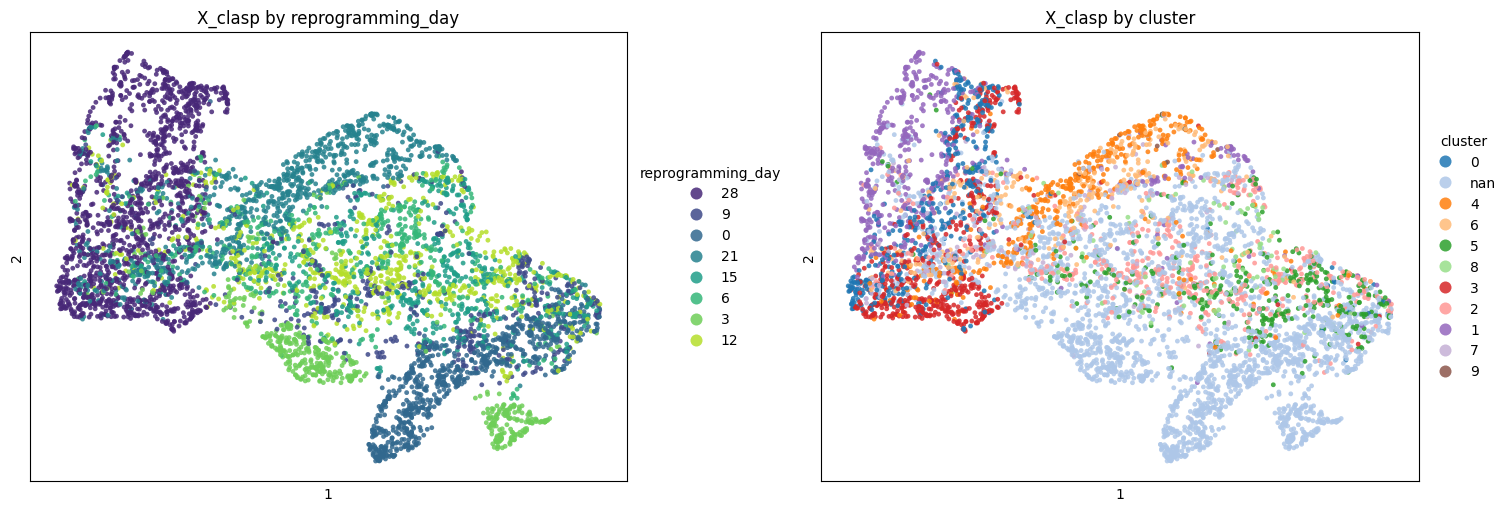

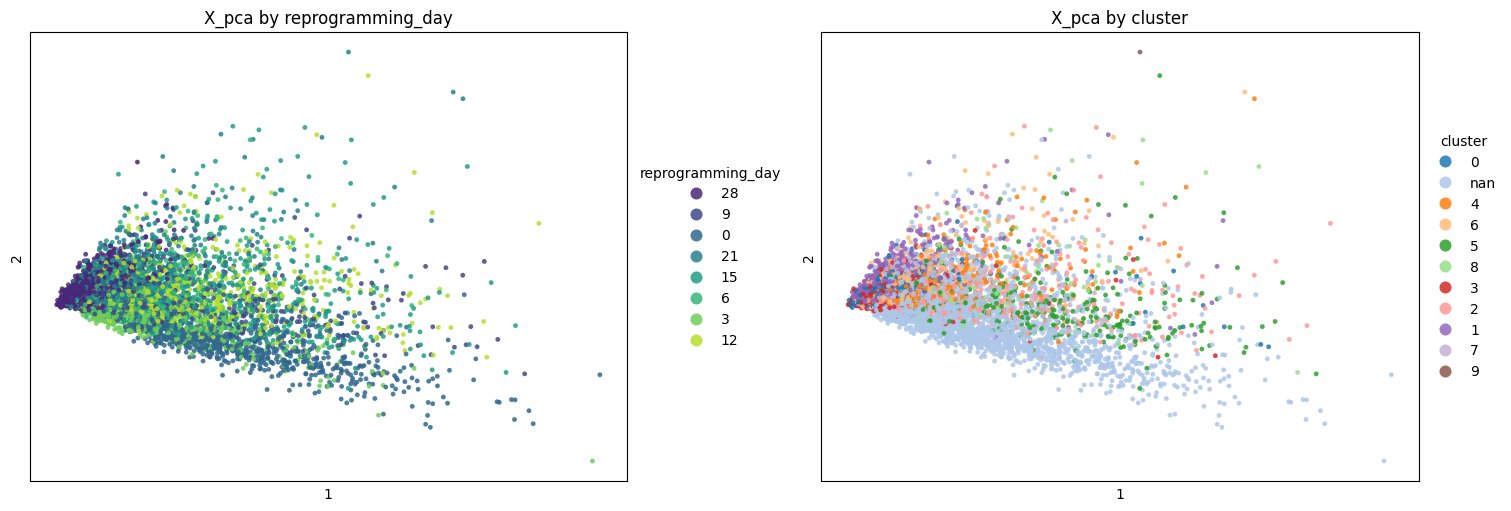

,8
dataset,cellrank_reprogramming_morris
input_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
params_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
status,optimized
best_model,pca
best_score,0.6187
pca_best_score,0.6187
gplvm_best_score,0.6092
optimized_preprocess_params,"{'n_top_genes': 1659, 'max_cells': 1000, 'min_..."
optimized_estimator_params,{'n_components': 76}


[10/10] zebrafish
status=optimized
best_model=pca
best_score=0.927
pca_best_score=0.927
gplvm_best_score=0.9255
preprocess params:
{
  "create_artificial_batch": false,
  "hvg_flavor": "variance",
  "max_cells": 1000,
  "min_cell_genes": null,
  "min_gene_counts": 3,
  "n_top_genes": 1341,
  "normalize": false
}
estimator params:
{
  "n_components": 94
}
graph params:
{
  "assignment_quantile": 0.30265713449594156,
  "edge_weighting": "distance",
  "hubness_correction": "csls",
  "hubness_k": 12,
  "inter_edge_mode": "assignment",
  "intra_fraction": 0.4876358896696807,
  "metric": "euclidean",
  "mutual_neighbors": true,
  "n_inter_edges": 3,
  "n_neighbors": 24,
  "neighbor_mode": "distance",
  "rank_correction": true,
  "symmetrize": true
}


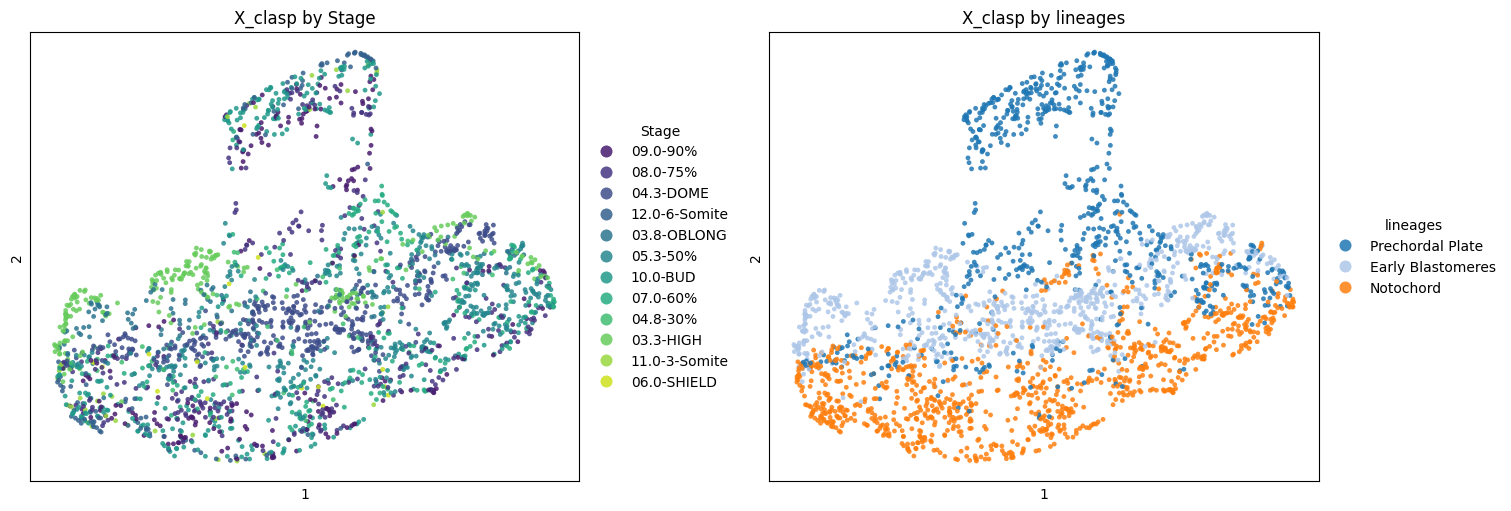

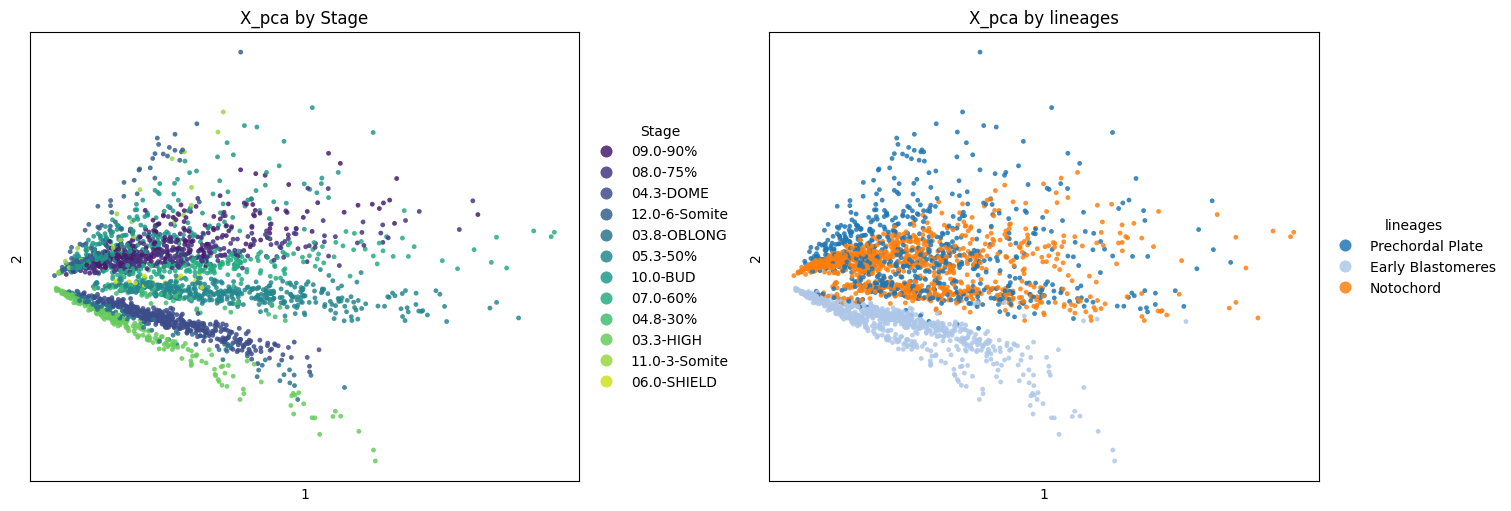

,9
dataset,zebrafish
input_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
params_path,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
status,optimized
best_model,pca
best_score,0.927
pca_best_score,0.927
gplvm_best_score,0.9255
optimized_preprocess_params,"{'n_top_genes': 1341, 'max_cells': 1000, 'min_..."
optimized_estimator_params,{'n_components': 94}


,dataset,input_path,params_path,status,best_model,best_score,pca_best_score,gplvm_best_score,optimized_preprocess_params,optimized_estimator_params,optimized_graph_params,visualization_status,clasp_figure_path,pca_figure_path,embedded_path
0,scib_pancreas,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,gplvm,1.07715,1.05435,1.07715,"{'create_artificial_batch': False, 'hvg_flavor...",{'n_components': 66},"{'assignment_quantile': 0.6350848740299995, 'e...",skipped_existing,NaN,NaN,NaN
1,scib_lung_atlas,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,pca,0.85180,0.85180,0.84640,"{'create_artificial_batch': False, 'hvg_flavor...",{'n_components': 83},"{'assignment_quantile': 0.1519602752593831, 'e...",skipped_existing,NaN,NaN,NaN
2,scib_immune_human,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,gplvm,0.91995,0.90955,0.91995,"{'create_artificial_batch': False, 'hvg_flavor...",{'n_components': 74},"{'assignment_quantile': 0.8741576013049732, 'e...",skipped_existing,NaN,NaN,NaN
3,scib_immune_human_mouse,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,gplvm,0.75690,0.71910,0.75690,"{'create_artificial_batch': False, 'hvg_flavor...",{'n_components': 78},"{'assignment_quantile': 0.3272518179827317, 'e...",skipped_existing,NaN,NaN,NaN
4,cellrank_bone_marrow,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,pca,0.81610,0.81610,0.80780,"{'create_artificial_batch': True, 'hvg_flavor'...",{'n_components': 100},"{'assignment_quantile': 0.35721224196130574, '...",skipped_existing,NaN,NaN,NaN
5,cellrank_lung,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,gplvm,0.63130,0.62330,0.63130,"{'create_artificial_batch': False, 'hvg_flavor...",{'n_components': 84},"{'assignment_quantile': 0.26545663498881933, '...",skipped_existing,NaN,NaN,NaN
6,cellrank_pancreas,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,pca,0.90810,0.90810,0.90370,"{'create_artificial_batch': True, 'hvg_flavor'...",{'n_components': 98},"{'assignment_quantile': 0.2861279020843537, 'e...",skipped_existing,NaN,NaN,NaN
7,cellrank_reprogramming_schiebinger,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,skipped_existing,pca,0.24070,0.24070,0.23970,"{'create_artificial_batch': False, 'hvg_flavor...",{'n_components': 40},"{'assignment_quantile': 0.7247903976194368, 'e...",skipped_existing,NaN,NaN,NaN
8,cellrank_reprogramming_morris,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,optimized,pca,0.61870,0.61870,0.60920,"{'n_top_genes': 1659, 'max_cells': 1000, 'min_...",{'n_components': 76},"{'n_neighbors': 25, 'intra_fraction': 0.307740...",generated,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...
9,zebrafish,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,optimized,pca,0.92700,0.92700,0.92550,"{'n_top_genes': 1341, 'max_cells': 1000, 'min_...",{'n_components': 94},"{'n_neighbors': 24, 'intra_fraction': 0.487635...",generated,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...,/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b6...


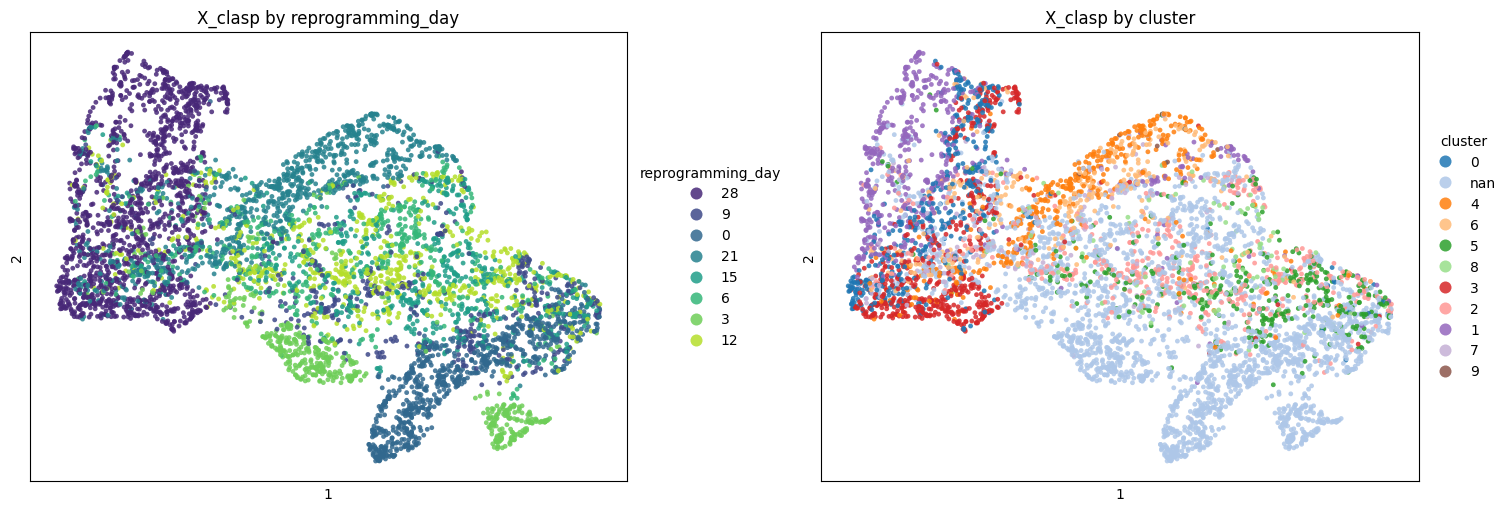

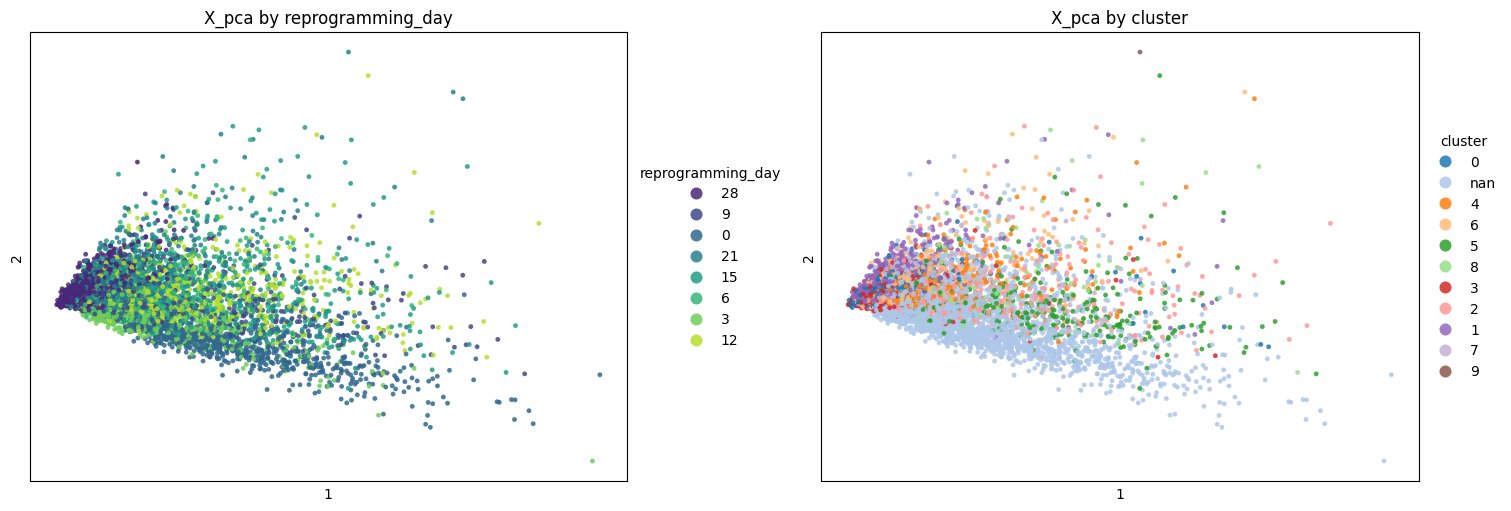

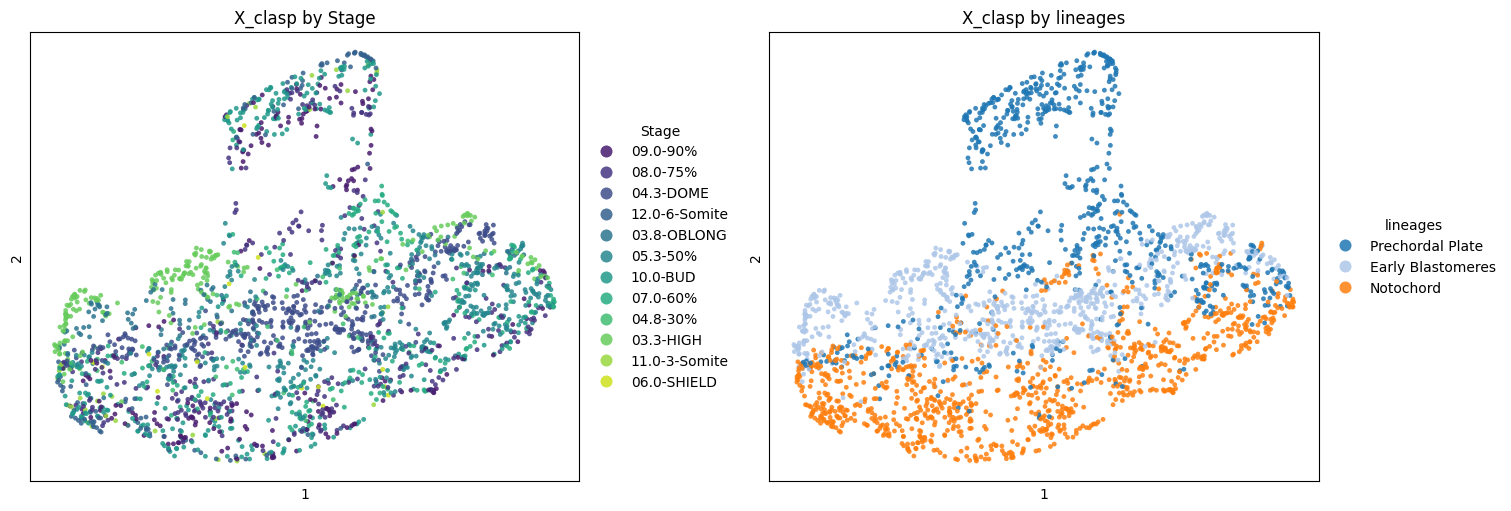

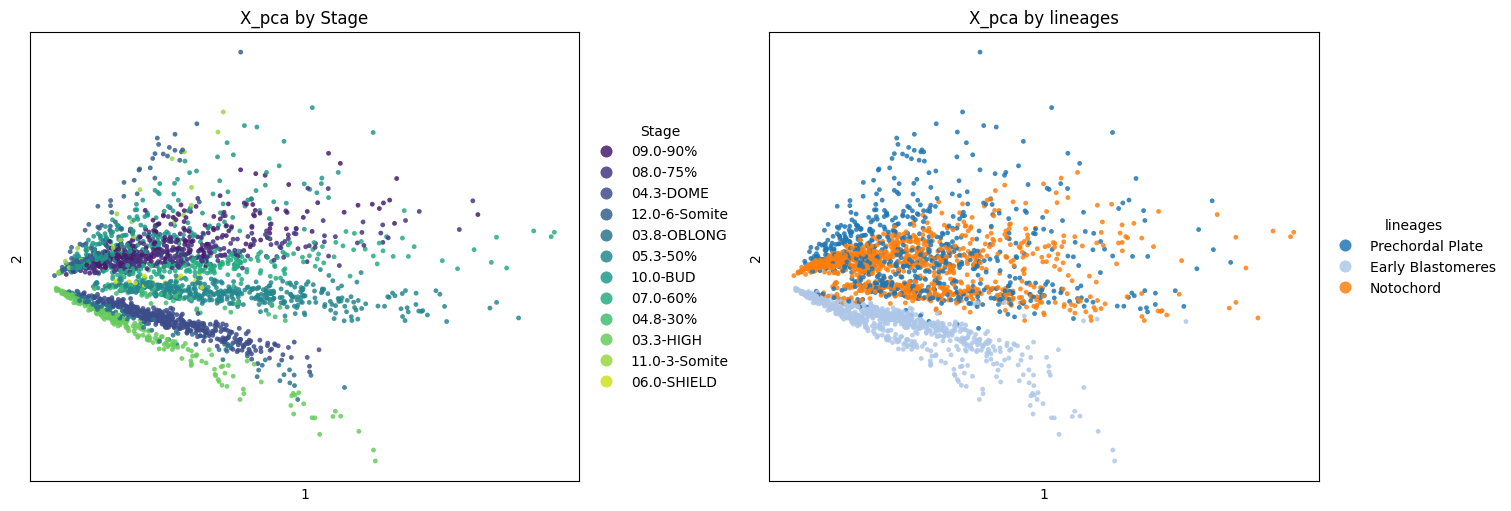

In [3]:
summary = run_dataset_optimization_sweep(
    selected_datasets,
    project_root=project_root,
    random_state=random_state,
    skip_missing_inputs=skip_missing_inputs,
    skip_existing_optimized=skip_existing_optimized,
    overwrite_existing=overwrite_existing,
    run_gplvm_refinement=run_gplvm_refinement,
    embedding_method=embedding_method,
    embedding_epochs=embedding_epochs,
    invalid_score=invalid_score,
    summary_path=summary_path,
    generate_figures=generate_figures,
    display_figures=display_figures,
    save_visualization=save_visualization,
    visualization_max_cells=visualization_max_cells,
    figure_dir=figure_dir,
    fixed_preprocess_params=fixed_preprocess_params,
    base_n_top_genes=base_n_top_genes,
    base_estimator_params=base_estimator_params,
    base_graph_params=base_graph_params,
    preprocess_search_space=preprocess_search_space,
    estimator_search_space=estimator_search_space,
    graph_search_space=graph_search_space,
    compact_radii=compact_radii,
    pca_bo_settings=pca_bo_settings,
    gplvm_bo_settings=gplvm_bo_settings,
    display_fn=display,
)

summary


The JSON parameter files written by this run are consumed directly by notebook 02:

```python
optimized_params = load_or_default_params(selected_dataset, dataset)
```

The CSV summary is only a run log; the JSON files in `data/optimized_params/` are the source of truth for downstream visualization and evaluation.